In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('pedidos_narashop.csv', sep= ';')
df ['valor_total'] = df['valor_unitario'] * df['quantidade']

df

,pedido_id,vendedor,categoria,produto,status_pedido,quantidade,valor_unitario,prazo_entrega_dias,valor_total
0,10001,Rafael Oliveira,Esportes,Raquete de Beach Tennis,Entregue,5,98.01,12,490.05
1,10002,Leandro Reis,Eletrônicos,SSD Externo,Entregue,4,599.89,8,2399.56
2,10003,Flávia Azevedo,Eletrônicos,Notebook,Entregue,5,3774.96,5,18874.80
3,10004,Lucas Ribeiro,Esportes,Garrafa Térmica,Entregue,1,87.67,4,87.67
4,10005,Vinícius Lopes,Eletrônicos,SSD Externo,Entregue,3,439.02,3,1317.06
...,...,...,...,...,...,...,...,...,...
19995,29996,Tatiane Cunha,Esportes,Raquete de Beach Tennis,Entregue,4,178.86,5,715.44
19996,29997,Ana Lima,Casa e Decoração,Tapete Sala,Em trânsito,4,166.27,5,665.08
19997,29998,Patrícia Rocha,Eletrônicos,Tablet,Cancelado,5,1577.65,4,7888.25
19998,29999,Alexandre Lacerda,Esportes,Bermuda Esportiva,Entregue,4,144.59,9,578.36


In [32]:
#2. O gerente quer saber quais categorias geraram mais receita. Apresente o faturamento total por categoria.

df_valor_categoria = df.groupby('categoria')['valor_total'].sum().reset_index()

#df_valor_categoria = df_valor_categoria.sort_values(by='valor_total', ascending=False)

df_valor_categoria.sort_values(by='valor_total', ascending=False, inplace=True) #quando uso o inplace true não é necesário repetir a variavel

df_valor_categoria

,categoria,valor_total
2,Eletrônicos,37037997.65
3,Esportes,8058234.35
1,Casa e Decoração,3333395.06
0,Brinquedos,2306126.65


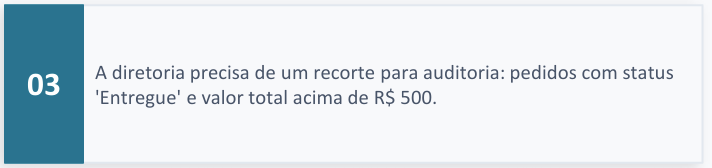

### A diretoria precisa de um recorte para auditoria: pedidos com status 'Entregue' e valor total acima de R$ 500.

In [33]:
#df_status_pedido = df.loc[df['status_pedido'] == 'Entregue']

df_entregue_acima_500 = df.loc[(df['status_pedido'] == 'Entregue') & (df['valor_total'] > 500)]

df_entregue_acima_500


,pedido_id,vendedor,categoria,produto,status_pedido,quantidade,valor_unitario,prazo_entrega_dias,valor_total
1,10002,Leandro Reis,Eletrônicos,SSD Externo,Entregue,4,599.89,8,2399.56
2,10003,Flávia Azevedo,Eletrônicos,Notebook,Entregue,5,3774.96,5,18874.80
4,10005,Vinícius Lopes,Eletrônicos,SSD Externo,Entregue,3,439.02,3,1317.06
19,10020,Renato Cavalcante,Eletrônicos,Smartwatch,Entregue,3,461.46,3,1384.38
25,10026,Larissa Nunes,Brinquedos,Telescópio Infantil,Entregue,5,487.03,2,2435.15
...,...,...,...,...,...,...,...,...,...
19987,29988,Sérgio Machado,Casa e Decoração,Fritadeira Air Fryer,Entregue,5,403.51,8,2017.55
19989,29990,Diego Fernandes,Esportes,Bicicleta Ergométrica,Entregue,1,1235.61,10,1235.61
19992,29993,Larissa Nunes,Casa e Decoração,Tapete Sala,Entregue,3,279.57,18,838.71
19995,29996,Tatiane Cunha,Esportes,Raquete de Beach Tennis,Entregue,4,178.86,5,715.44


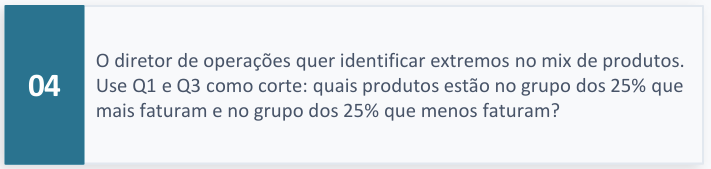

In [34]:
#criação df produto

df_produto = df.groupby('produto')['valor_total'].sum().reset_index() 
df_produto.sort_values(by='valor_total', ascending=False, inplace=True)
df_produto.head(3)

,produto,valor_total
27,Notebook,15091721.74
37,Smart TV,8474171.95
38,Smartphone,6806241.19


In [35]:
array_valor_produto = np.array(df_produto['valor_total']) #array trabalha com calculos em grande volume é uma boa pratica utiliza-lo
q1 = np.percentile(array_valor_produto, 25)
q3 = np.percentile(array_valor_produto, 75)

iqr = q3 -q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 -(1.5 * iqr)
print(f"Limite superior: {limite_superior}")
print(f"Limite inferior: {limite_inferior}")

Limite superior: 808072.59125
Limite inferior: -366652.59875


In [36]:
df_produto_outliers = df_produto.loc[df_produto['valor_total'] > limite_superior]
df_produto_outliers

,produto,valor_total
27,Notebook,15091721.74
37,Smart TV,8474171.95
38,Smartphone,6806241.19
1,Bicicleta Ergométrica,5949159.26
40,Tablet,3258725.63
39,Smartwatch,1344856.80
13,Fritadeira Air Fryer,980636.15


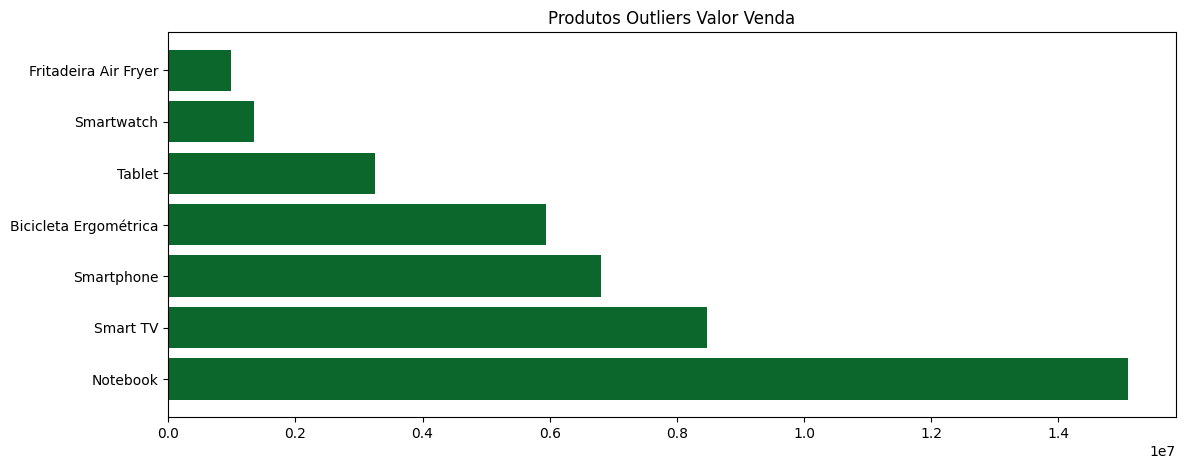

In [44]:
plt.figure(figsize=(13,5))
plt.barh(df_produto_outliers['produto'],df_produto_outliers['valor_total'], color='#0b672c')
#plt.bar(categorias, valores, color='#0b672c')
plt.title('Produtos Outliers Valor Venda')
plt.show()

In [ ]:
df_produto_25_mais = df_produto.loc[df_produto['valor_total'] > q3]
df_produto_25_mais

,produto,valor_total
27,Notebook,15091721.74
37,Smart TV,8474171.95
38,Smartphone,6806241.19
1,Bicicleta Ergométrica,5949159.26
40,Tablet,3258725.63
39,Smartwatch,1344856.80
13,Fritadeira Air Fryer,980636.15
17,Jogo de Panelas,760544.58
36,SSD Externo,719921.59
45,Tênis de Corrida,696912.40


In [ ]:
df_produto_25_menos = df_produto.loc[df_produto['valor_total'] < q1]
df_produto_25_menos

,produto,valor_total
0,Bermuda Esportiva,73266.61
8,Conjunto de Toalhas,70889.32
6,Carregador Portátil,64156.00
14,Garrafa Térmica,63532.51
10,Difusor de Aromas,57532.21
34,Quebra-Cabeça 1000 peças,51701.41
30,Pelúcia,51088.67
42,Tapete de Yoga,50209.91
28,Organizador de Gavetas,36586.33
32,Porta-Retratos,26224.38


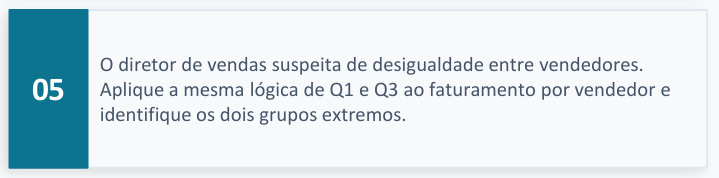

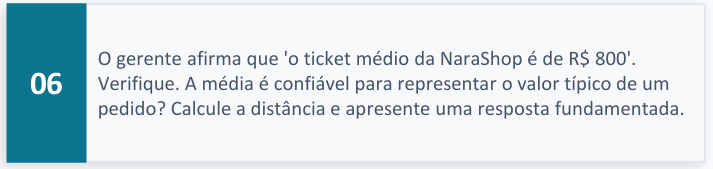

In [ ]:
array_valor_pedido = np.array(df['valor_total'])
media = np.mean(array_valor_pedido)
mediana = np.median(array_valor_pedido)
distancia = (media - mediana)/mediana

print(f'A média é de {media} e a Mediana é de {mediana}')
print(f'A distancia entre a Média e a Mediana é de {distancia:.2%}')


A média é de 2536.7876855 e a Mediana é de 882.635
A distancia entre a Média e a Mediana é de 187.41%


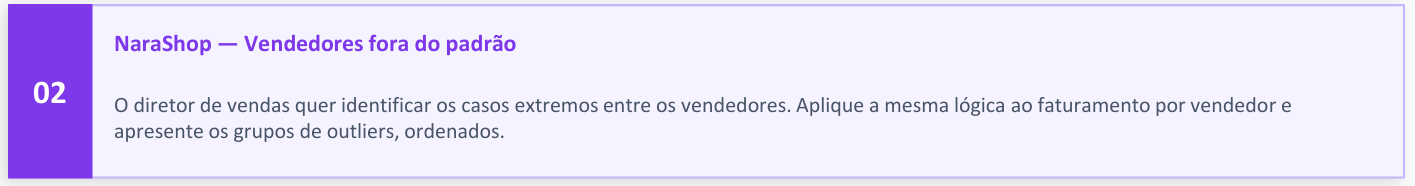

In [ ]:
df_vendedor = df.groupby('vendedor')['valor_total'].sum().reset_index() 
df_vendedor.sort_values(by='valor_total', ascending=False, inplace=True)
df_vendedor.head(5)

,vendedor,valor_total
3,Ana Lima,3950687.71
35,Rafael Oliveira,3934561.13
23,Juliana Martins,3226272.18
12,Diego Fernandes,3180786.47
8,Carlos Souza,3065164.09


In [ ]:
array_valor_vendedor = np.array(df_vendedor['valor_total']) #array trabalha com calculos em grande volume é uma boa pratica utiliza-lo
q1 = np.percentile(array_valor_vendedor, 25)
q3 = np.percentile(array_valor_vendedor, 75)

iqr = q3 -q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 -(1.5 * iqr)
print(f"Limite superior: {limite_superior}")
print(f"Limite inferior: {limite_inferior}")

Limite superior: 1868670.24375
Limite inferior: -518125.8862499999


In [ ]:
df_vendedor_outliers = df_vendedor.loc[df_vendedor['valor_total'] > limite_superior]
df_vendedor_outliers

,vendedor,valor_total
3,Ana Lima,3950687.71
35,Rafael Oliveira,3934561.13
23,Juliana Martins,3226272.18
12,Diego Fernandes,3180786.47
8,Carlos Souza,3065164.09
32,Patrícia Rocha,3008726.29
6,Bruno Alves,2894957.47
17,Fernanda Costa,2855540.29


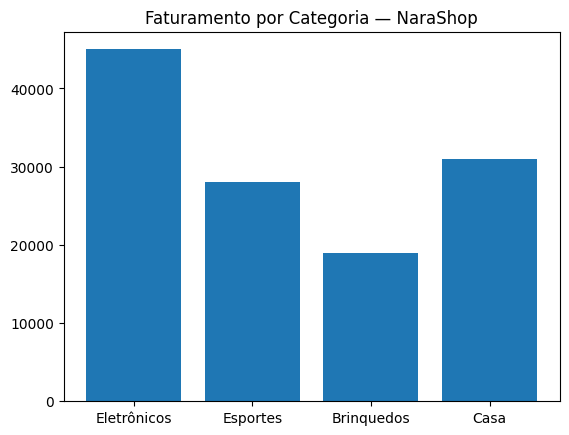

In [ ]:
categorias = ['Eletrônicos', 'Esportes', 'Brinquedos', 'Casa']
valores = [45000, 28000, 19000, 31000]
plt.bar(categorias, valores)
plt.title('Faturamento por Categoria — NaraShop')
plt.show()

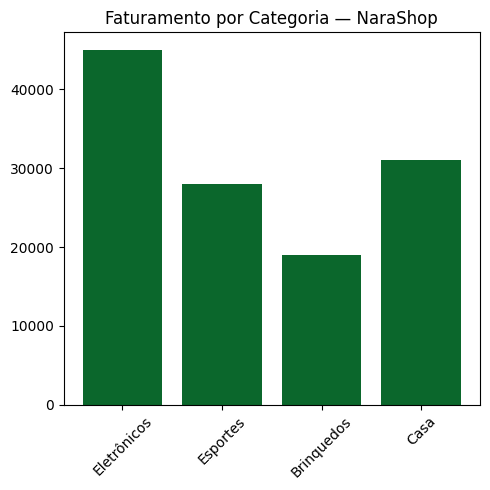

In [ ]:
plt.figure(figsize=(5, 5))          
# largura x altura em polegadas
plt.bar(categorias, valores, color='#0b672c')
plt.title('Faturamento por Categoria — NaraShop')
plt.xticks(rotation=45)                
plt.tight_layout()                  
plt.show()